In [2]:
try:
    import torch
    import torchvision
    assert int(torch.__version__.split(".")[1])>=12
    assert int(torchvision.__version__.split(".")[1])>=27
    print(f"torch version :{torch.__version__}")
    print(f"torchvision version :{torchvision.__version__}")
except:
    print(f"[info] torch/torchvision version mismatch or not installed ")
    !pip3 install -U torch torchvision
    import torch 
    import torchvision
    print(f"torch version :{torch.__version__}")
    print(f"torchvision version :{torchvision.__version__}")



torch version :2.13.0+cpu
torchvision version :0.28.0+cpu


In [3]:
import matplotlib.pyplot as plt
import torch
import torchvision
from torch import nn
from torchvision import transforms

try:
    from torchinfo import summary
except:
    print("[info] coudnt find torchinfo... installing")
    !pip3 install -q torchinfo
    from torchinfo import summary

try:
    from going_modular import data_setup,engine
except:
    print("coudnt find downloading from github")
    !git clone https://github.com/Sunny-Kumar-1/Deep-Learning.git
    !mv pytorch/going_modular .
    !rm -rf pytorch 
    from going_modular import data_setup,engine






c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [5]:
import os
from pathlib import Path
import zipfile
import requests

data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

if image_path.is_dir():
    print("image path exist.")
else:
    image_path.mkdir(parents=True,exist_ok=True)

    with open(data_path/"pizza_steak_sushi.zip","wb") as f:
        request = requests.get("https://github.com/Sunny-Kumar-1/Deep-Learning/blob/transfer/pytorch/data/pizza_steak_sushi.zip")
        f.write(request.content)

    with zipfile.ZipFile(data_path/"pizza_steak_sushi.zip","r") as zipfile:
        zipfile.extractall(image_path)

    os.remove(data_path/"pizza_steak_sushi.zip")


image path exist.


In [6]:
train_dir = image_path/"train"
test_dir=image_path/"test"

In [7]:
manual_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

In [8]:
train_dataloader,test_dataloader,class_names= data_setup.create_dataloaders(train_dir=train_dir,
                                                                            test_dir=test_dir,
                                                                            transform=manual_transforms,
                                                                            batch_size=32)
train_dataloader,test_dataloader,class_names

(<torch.utils.data.dataloader.DataLoader at 0x29006aab0e0>,
 ['pizza', 'steak', 'sushi'])

In [9]:
weight1 = torchvision.models.EfficientNet_B0_Weights.DEFAULT
weight2 = torchvision.models.RegNet_Y_128GF_Weights.IMAGENET1K_SWAG_E2E_V1
weight1,weight2

(EfficientNet_B0_Weights.IMAGENET1K_V1,
 RegNet_Y_128GF_Weights.IMAGENET1K_SWAG_E2E_V1)

In [10]:
auto_transforms = weight1.transforms()
auto_transforms2 = weight2.transforms()

auto_transforms,auto_transforms2

(ImageClassification(
     crop_size=[224]
     resize_size=[256]
     mean=[0.485, 0.456, 0.406]
     std=[0.229, 0.224, 0.225]
     interpolation=InterpolationMode.BICUBIC
 ),
 ImageClassification(
     crop_size=[384]
     resize_size=[384]
     mean=[0.485, 0.456, 0.406]
     std=[0.229, 0.224, 0.225]
     interpolation=InterpolationMode.BICUBIC
 ))

In [11]:
train_dataloader,test_dataloader,class_names=data_setup.create_dataloaders(train_dir,
                                                                           test_dir,
                                                                           auto_transforms,
                                                                           32)
train_dataloader,test_dataloader,class_names

(<torch.utils.data.dataloader.DataLoader at 0x29006a33d90>,
 ['pizza', 'steak', 'sushi'])

In [12]:
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
model = torchvision.models.efficientnet_b0(weights=weights).to(device)


In [13]:
summary(model=model,
        input_size=(32,3,224,224),
        col_names=["input_size","output_size","num_params","trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 1000]           --                   True
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   True
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   True
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   864                  True
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   64                   True
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 16, 112

In [14]:
for param in model.features.parameters():
    param.requires_grad=False

In [15]:
summary(model=model,
        input_size=(32,3,224,224),
        col_names=["input_size","output_size","num_params","trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 1000]           --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

In [16]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

output_shape = len(class_names)

model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2,inplace=True),
    torch.nn.Linear(in_features=1280,
                    out_features=output_shape,
                    bias=True).to(device)
)

In [17]:
summary(model=model,
        input_size=(32,3,224,224),
        col_names=["input_size","output_size","num_params","trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

In [18]:
loss_fn = torch.nn.CrossEntropyLoss()
opitimizer = torch.optim.Adam(model.parameters(),lr=0.001)

In [19]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

from timeit import default_timer as Timer
start = Timer()
result = engine.train(model,
                      train_dataloader,
                      test_dataloader,
                      opitimizer,
                      loss_fn,
                      5,
                      device)

end = Timer()
print(f"{end-start:.3f}s")

  0%|          | 0/5 [00:00<?, ?it/s]

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
 20%|██        | 1/5 [00:25<01:41, 25.36s/it]

Epoch: 1 | train_loss: 1.0883 | train_acc: 0.4180 | test_loss: 0.8914 | test_acc: 0.6818


 40%|████      | 2/5 [00:42<01:01, 20.38s/it]

Epoch: 2 | train_loss: 0.9162 | train_acc: 0.6289 | test_loss: 0.8027 | test_acc: 0.7443


...

Epoch: 3 | train_loss: 0.8162 | train_acc: 0.7031 | test_loss: 0.6787 | test_acc: 0.9072


 80%|████████  | 4/5 [01:15<00:17, 17.94s/it]

Epoch: 4 | train_loss: 0.7460 | train_acc: 0.7305 | test_loss: 0.6744 | test_acc: 0.8040


100%|██████████| 5/5 [01:33<00:00, 18.73s/it]

Epoch: 5 | train_loss: 0.6209 | train_acc: 0.7695 | test_loss: 0.6263 | test_acc: 0.8561
93.643s


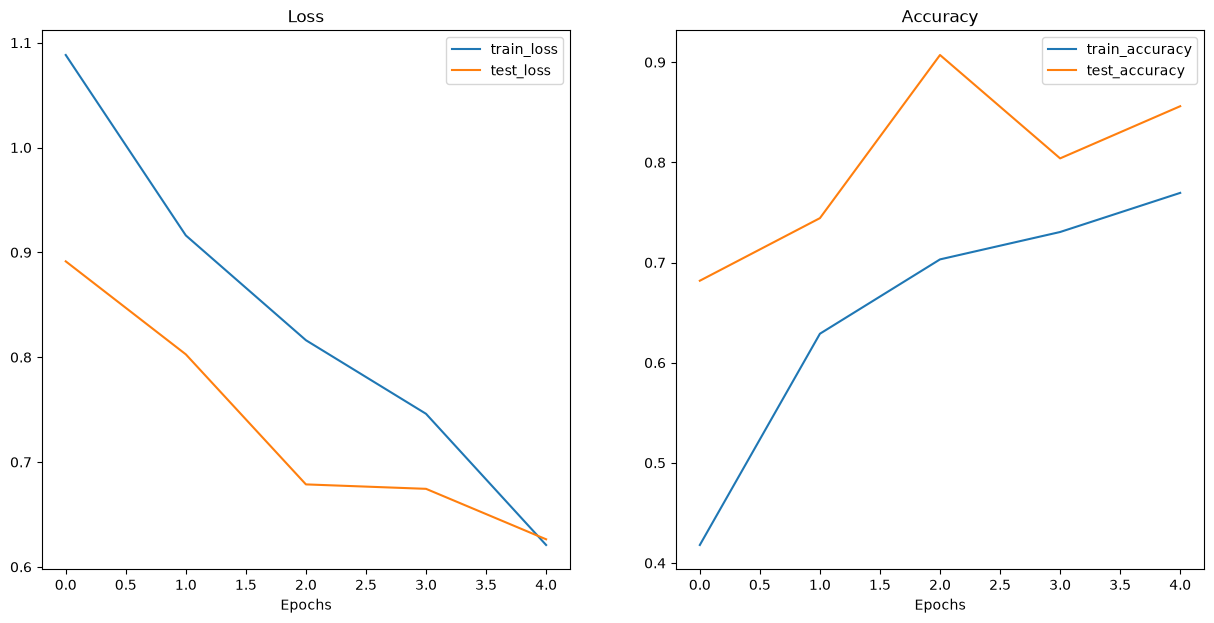

In [20]:
from helper_functions import plot_loss_curves
plot_loss_curves(result)

In [24]:
from typing import List,Tuple
from PIL import Image
import torchvision
from torchvision import transforms

def pred_and_plot_image(model:torch.nn.Module,
                        image_path:str,
                        class_names:List[str],
                        image_size:Tuple[int,int] = (224,224),
                        transform: torchvision.transforms = None,
                        device: torch.device=device):
    img = Image.open(image_path)

    if transform is not None:
        image_transform = transform
    else:
        image_transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    model.eval()
    with torch.inference_mode():
        transformed_image = image_transform(img).unsqueeze(dim=0)
        
        target_image_pred = model(transformed_image.to(device))
    target_image_pred_prob  = torch.softmax(target_image_pred,dim=1)
    target_image_pred_label = torch.argmax(target_image_pred_prob,dim=1)
    plt.figure()
    plt.imshow(img)
    plt.title(f"pred: {class_names[target_image_pred_label]} | prob : {target_image_pred_prob.max():.3f}")
    plt.axis(False)

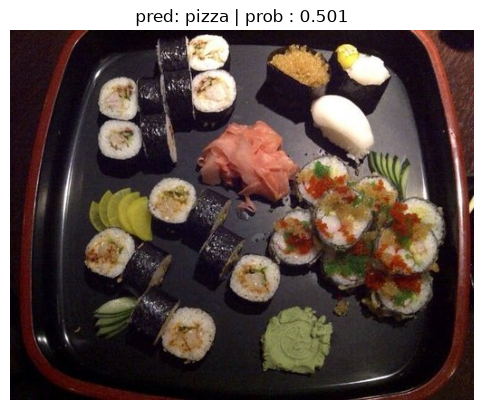

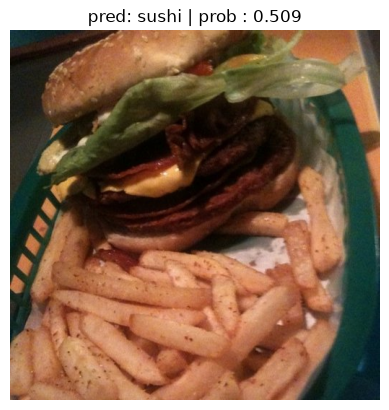

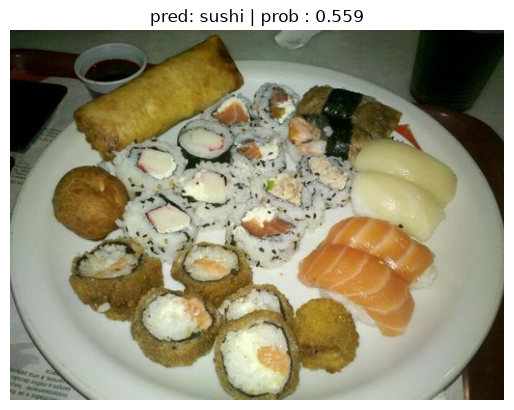

In [31]:
import random
num_image_to_plot = 3
test_image_path_list = list(Path(test_dir).glob("*/*.jpg"))
test_image_path_sample = random.sample(population=test_image_path_list,k=num_image_to_plot)
for image_path in test_image_path_sample:
    pred_and_plot_image(model,image_path,class_names,image_size=(224,224))

data\04-pizza-dad.jpeg already exists, skipping download.


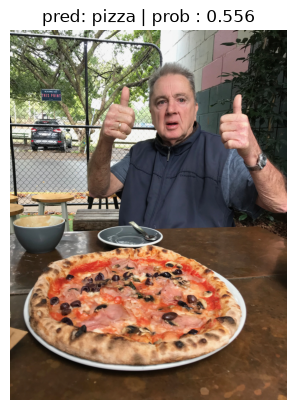

In [ ]:
import requests

custom_image_path = data_path / "04-pizza-dad.jpeg"

if not custom_image_path.is_file():
    with open(custom_image_path, "wb") as f:
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
        print(f"Downloading {custom_image_path}...")
        f.write(request.content)
else:
    print(f"{custom_image_path} already exists, skipping download.")

pred_and_plot_image(model=model,
                    image_path=custom_image_path,
                    class_names=class_names)